# 📊 Estudio de Caso M&A — Gildan Activewear adquiere Hanesbrands (2025)
### Finanzas Corporativas · Valuation · Data Analytics
---
**Estudio de Caso**

> *"Gildan pagó un múltiplo deprimido por activos de alto valor estratégico.  
> En este notebook modelamos la adquisición como lo haría un analista de M&A."*

---
## Sección 1 — Fundamentos Teóricos de M&A

### ¿Qué es una Fusión y Adquisición?

En finanzas corporativas, el término **M&A (Mergers & Acquisitions)** describe transacciones donde dos empresas se combinan. Existen tres formas principales:

| Tipo | Descripción | Ejemplo |
|---|---|---|
| **Adquisición** | Una empresa compra otra. La target deja de existir de forma independiente. | ✅ Este caso: Gildan compra Hanesbrands |
| **Fusión (Merger of equals)** | Dos empresas de tamaño similar se combinan en una nueva entidad | Exxon + Mobil → ExxonMobil |
| **Consolidación** | Ambas desaparecen y crean una empresa completamente nueva | Empresa A + B → Nueva empresa C |

### Tipos de Integración

- **Horizontal**: Mismo sector. Busca escala y reducción de costos. → *Este caso.*
- **Vertical**: Compra proveedor o distribuidor. Busca control de la cadena de valor.
- **Conglomerado**: Sectores distintos. Busca diversificación.

---

### Conceptos Clave de Valuación

**Enterprise Value (EV)**
$$EV = \text{Market Cap} + \text{Deuda Total} - \text{Caja}$$
El EV es el "precio real" de una empresa: el comprador **hereda la deuda**, por eso se suma.

**Múltiplo EV/EBITDA**  
El múltiplo más usado en M&A. Permite comparar empresas independientemente de su estructura de capital.
- Industria apparel promedio: ~12.5x
- Deal Gildan–Hanes: ~8.8x → **barato**

**Premium de Adquisición**
$$\text{Premium} = \frac{\text{Precio oferta} - \text{Precio pre-deal}}{\text{Precio pre-deal}}$$

**Sinergias**  
Valor adicional que se crea al combinar las empresas. *"El todo vale más que la suma de las partes."*

**Accretion / Dilution**  
Si el EPS combinado > EPS pre-deal → **accretive** ✅  (Se generan mas ganancias que antes)

Si el EPS combinado < EPS pre-deal → **dilutive** ❌ (Las ganancias se diluyen)

**Distressed M&A**  
Cuando la empresa objetivo tiene problemas financieros y el precio está deprimido. El comprador aprovecha la situación. → *Hanesbrands tenía ~USD 3B de deuda y ventas en caída.*

---
## Sección 2 — Datos Reales del Deal

Todos los datos provienen de fuentes públicas: Gildan IR, GlobeNewswire, WSJ, AP News, SEC filings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ── Parámetros del deal (fuente: GlobeNewswire / Gildan IR / WSJ / AP News)
DEAL = {
    'equity_value_b':         2.20,
    'enterprise_value_b':     4.40,
    'offer_price_per_share':  6.00,
    'pre_deal_price':         4.80,   # precio HBI ~30 días antes del anuncio
    'pct_stock':              0.87,
    'pct_cash':               0.13,
    'synergies_initial_m':    200,
    'synergies_revised_m':    250,
    'announce_date':          '2025-08-13',
    'close_date':             '2025-12-01',
}

# ── Financials trailing 12 meses en USD millones (fuente: Gildan IR / SEC / Bloomberg)
GILDAN = {
    'ticker': 'GIL', 'revenue': 3_190, 'ebitda': 856.6,
    'ebit': 700, 'net_income': 540,
    'total_debt': 1_200, 'cash': 350, 'shares_mm': 170, 'market_cap_b': 7.5,
    'ebitda_margin': 0.268, 'revenue_growth_yoy': 0.04,
}

HANESBRANDS = {
    'ticker': 'HBI', 'revenue': 3_535, 'ebitda': 497.2,
    'ebit': 290, 'net_income': -120,
    'total_debt': 2_850, 'cash': 310, 'shares_mm': 356, 'market_cap_b': 2.2,
    'ebitda_margin': 0.141, 'revenue_growth_yoy': -0.08,
    'peak_mcap_m': 14_000,   # pico histórico 2015-2017
}

WACC = 0.085
GROWTH_PERP = 0.02

def calc_ev(market_cap_b, debt_m, cash_m):
    return market_cap_b * 1000 + debt_m - cash_m

GIL_EV  = calc_ev(GILDAN['market_cap_b'],     GILDAN['total_debt'],     GILDAN['cash'])
HBI_EV  = calc_ev(HANESBRANDS['market_cap_b'],HANESBRANDS['total_debt'],HANESBRANDS['cash'])
DEAL_EV = DEAL['enterprise_value_b'] * 1000

print("✅ Datos cargados correctamente.")
print(f"   Gildan EV:       ${GIL_EV:,.0f}M")
print(f"   Hanesbrands EV:  ${HBI_EV:,.0f}M")
print(f"   Deal EV pagado:  ${DEAL_EV:,.0f}M")

✅ Datos cargados correctamente.
   Gildan EV:       $8,350M
   Hanesbrands EV:  $4,740M
   Deal EV pagado:  $4,400M


### Resumen financiero comparativo

In [2]:
summary = pd.DataFrame({
    'Empresa':         ['Gildan (GIL)', 'Hanesbrands (HBI)'],
    'Revenue (MM USD)':[GILDAN['revenue'], HANESBRANDS['revenue']],
    'EBITDA (MM USD)': [GILDAN['ebitda'], HANESBRANDS['ebitda']],
    'Margen EBITDA %': [round(GILDAN['ebitda_margin']*100,1),
                        round(HANESBRANDS['ebitda_margin']*100,1)],
    'EV (MM USD)':     [GIL_EV, HBI_EV],
    'EV/EBITDA':       [round(GIL_EV/GILDAN['ebitda'],1),
                        round(HBI_EV/HANESBRANDS['ebitda'],1)],
    'Net Income (MM)': [GILDAN['net_income'], HANESBRANDS['net_income']],
    'Deuda Neta (MM)': [GILDAN['total_debt']-GILDAN['cash'],
                        HANESBRANDS['total_debt']-HANESBRANDS['cash']],
})
summary

,Empresa,Revenue (MM USD),EBITDA (MM USD),Margen EBITDA %,EV (MM USD),EV/EBITDA,Net Income (MM),Deuda Neta (MM)
0,Gildan (GIL),3190,856.6,26.8,8350.0,9.7,540,850
1,Hanesbrands (HBI),3535,497.2,14.1,4740.0,9.5,-120,2540


---
## Sección 3 — Enterprise Value & Deal Valuation

El **Enterprise Value** es el concepto central en M&A porque el comprador no solo paga por las acciones: **hereda toda la deuda** de la empresa adquirida.

$$EV = \text{Equity Value} + \text{Deuda Neta}$$

En este deal:
- Equity Value pagado: **USD 2.2B**
- Deuda Hanesbrands heredada: **~USD 2.5B neta**
- **Enterprise Value total: USD 4.4B**

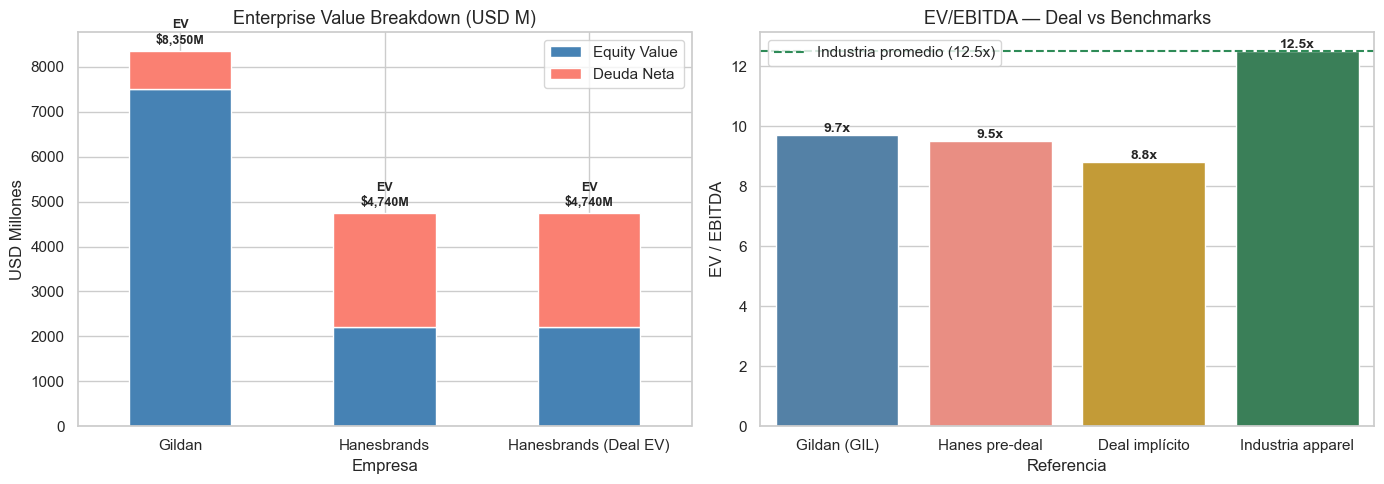

Premium de adquisición:              25.0%
Múltiplo deal:                       8.8x EV/EBITDA
Descuento vs industria (12.5x):      29.2%  ← ganga
Destrucción de valor histórica HBI:  84%  ← distressed


In [4]:
# ── EV Breakdown de ambas empresas
ev_data = pd.DataFrame({
    'Empresa':      ['Gildan', 'Hanesbrands', 'Hanesbrands (Deal EV)'],
    'Equity Value': [GILDAN['market_cap_b']*1000,
                     HANESBRANDS['market_cap_b']*1000,
                     DEAL['equity_value_b']*1000],
    'Deuda Neta':   [GILDAN['total_debt']-GILDAN['cash'],
                     HANESBRANDS['total_debt']-HANESBRANDS['cash'],
                     HANESBRANDS['total_debt']-HANESBRANDS['cash']],
})
ev_data['EV Total'] = ev_data['Equity Value'] + ev_data['Deuda Neta']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: EV Breakdown (stacked bar)
ev_plot = ev_data.set_index('Empresa')[['Equity Value','Deuda Neta']]
ev_plot.plot(kind='bar', stacked=True, ax=axes[0], rot=0,
             color=['steelblue','salmon'])
for i, total in enumerate(ev_data['EV Total']):
    axes[0].text(i, total + 100, f'EV\n${total:,.0f}M',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Enterprise Value Breakdown (USD M)', fontsize=13)
axes[0].set_ylabel('USD Millones')
axes[0].legend(loc='upper right')

# Gráfico 2: EV/EBITDA implícito del deal vs industria
multiples_df = pd.DataFrame({
    'Referencia': ['Gildan (GIL)', 'Hanes pre-deal', 'Deal implícito', 'Industria apparel'],
    'EV/EBITDA':  [round(GIL_EV/GILDAN['ebitda'],1),
                   round(HBI_EV/HANESBRANDS['ebitda'],1),
                   round(DEAL_EV/HANESBRANDS['ebitda'],1),
                   12.5],
    'Tipo': ['Acquirer', 'Target', 'Deal', 'Benchmark']
})
palette = {'Acquirer':'steelblue','Target':'salmon','Deal':'goldenrod','Benchmark':'seagreen'}
sns.barplot(data=multiples_df, x='Referencia', y='EV/EBITDA',
            hue='Tipo', palette=palette, ax=axes[1], dodge=False, legend=False)
axes[1].axhline(12.5, color='seagreen', linewidth=1.5, linestyle='--',
                label='Industria promedio (12.5x)')
for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.1,
                 f'{h:.1f}x', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('EV/EBITDA — Deal vs Benchmarks', fontsize=13)
axes[1].set_ylabel('EV / EBITDA')
axes[1].legend()
plt.tight_layout()
plt.show()

premium = (DEAL['offer_price_per_share'] - DEAL['pre_deal_price']) / DEAL['pre_deal_price']
discount_vs_industry = (1 - (DEAL_EV/HANESBRANDS['ebitda']) / 12.5)
print(f"Premium de adquisición:              {premium*100:.1f}%")
print(f"Múltiplo deal:                       {DEAL_EV/HANESBRANDS['ebitda']:.1f}x EV/EBITDA")
print(f"Descuento vs industria (12.5x):      {discount_vs_industry*100:.1f}%  ← ganga")
print(f"Destrucción de valor histórica HBI:  {(1 - HANESBRANDS['market_cap_b']*1000/HANESBRANDS['peak_mcap_m'])*100:.0f}%  ← distressed")

---
## Sección 4 — Análisis de Sinergias y NPV

Las **sinergias** son el valor adicional que se crea al combinar las dos empresas. Gildan estimó **USD 200M anuales**, luego revisadas a **USD 250M** tras el cierre.

**Tipos de sinergias en este deal:**
1. **Costos**: Gildan produce ropa Hanes con su manufactura más barata (Honduras, Nicaragua)
2. **Compras**: mayor escala para negociar algodón
3. **Corporativas**: eliminar duplicaciones de management, IT, back-office

**Modelo de 2 etapas para el NPV:**
- Fase 1 (años 1-3): ramp-up progresivo (30% → 65% → 100% de sinergias)
- Fase 2 (años 4-10): estado estable
- Terminal Value: Gordon Growth Model con g = 2%

In [5]:
def npv_synergies(annual_m, wacc=WACC, g=GROWTH_PERP, years=10):
    """NPV de sinergias con ramp-up de 3 años y terminal value."""
    ramp = [0.30, 0.65, 1.00]
    cfs = [annual_m * r / (1 + wacc)**(i+1) for i, r in enumerate(ramp)]
    cfs += [annual_m / (1 + wacc)**yr for yr in range(4, years+1)]
    tv = (annual_m * (1 + g)) / (wacc - g) / (1 + wacc)**years
    return sum(cfs) + tv

# Análisis de escenarios
scenarios = pd.DataFrame({
    'Escenario':        ['Bear', 'Base', 'Revisado (real)', 'Bull'],
    'Sinergias (M/año)':[100, 200, 250, 400],
})
scenarios['NPV Sinergias (M)'] = scenarios['Sinergias (M/año)'].apply(npv_synergies).round(0)
premium_paid = (DEAL['offer_price_per_share'] - DEAL['pre_deal_price']) * HANESBRANDS['shares_mm']
scenarios['Premium pagado (M)'] = premium_paid
scenarios['Valor creado neto (M)'] = (scenarios['NPV Sinergias (M)'] - premium_paid).round(0)
scenarios['¿Crea valor?'] = scenarios['Valor creado neto (M)'].apply(lambda x: '✅ Sí' if x > 0 else '❌ No')
print(f"WACC: {WACC*100:.1f}%  |  g perpetuidad: {GROWTH_PERP*100:.1f}%  |  Premium pagado: ${premium_paid:,.0f}M")
scenarios

WACC: 8.5%  |  g perpetuidad: 2.0%  |  Premium pagado: $427M


,Escenario,Sinergias (M/año),NPV Sinergias (M),Premium pagado (M),Valor creado neto (M),¿Crea valor?
0,Bear,100,1256.0,427.2,829.0,✅ Sí
1,Base,200,2512.0,427.2,2085.0,✅ Sí
2,Revisado (real),250,3140.0,427.2,2713.0,✅ Sí
3,Bull,400,5024.0,427.2,4597.0,✅ Sí


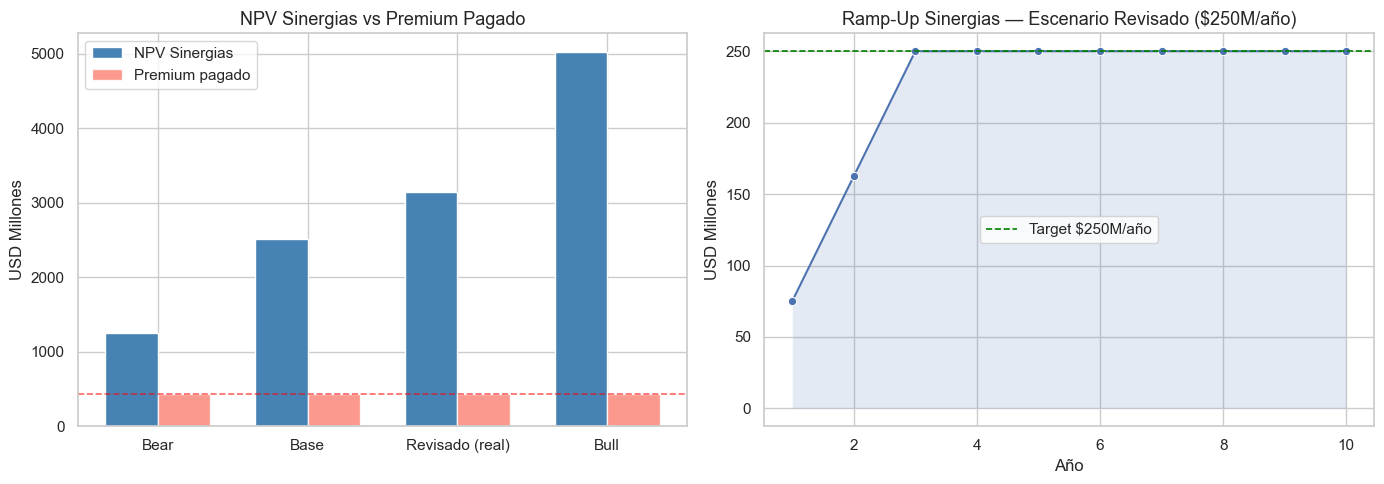

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: NPV vs Premium pagado por escenario
x = np.arange(len(scenarios))
width = 0.35
axes[0].bar(x - width/2, scenarios['NPV Sinergias (M)'], width, label='NPV Sinergias', color='steelblue')
axes[0].bar(x + width/2, scenarios['Premium pagado (M)'], width, label='Premium pagado', color='salmon', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(scenarios['Escenario'])
axes[0].axhline(premium_paid, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
axes[0].set_title('NPV Sinergias vs Premium Pagado', fontsize=13)
axes[0].set_ylabel('USD Millones')
axes[0].legend()

# Gráfico 2: Ramp-up anual de sinergias (escenario revisado)
syn_rev = DEAL['synergies_revised_m']
years_syn = list(range(1, 11))
annual_syn = [syn_rev * r for r in [0.30, 0.65, 1.0]] + [syn_rev] * 7
syn_df = pd.DataFrame({'Año': years_syn, 'Sinergias realizadas (M)': annual_syn})
sns.lineplot(data=syn_df, x='Año', y='Sinergias realizadas (M)', ax=axes[1], marker='o')
axes[1].axhline(syn_rev, color='green', linestyle='--', linewidth=1.2,
                label=f'Target ${syn_rev}M/año')
axes[1].fill_between(syn_df['Año'], syn_df['Sinergias realizadas (M)'], alpha=0.15)
axes[1].set_title(f'Ramp-Up Sinergias — Escenario Revisado (${syn_rev}M/año)', fontsize=13)
axes[1].set_ylabel('USD Millones')
axes[1].legend()
plt.tight_layout()
plt.show()

**Gráfico izquierdo (NPV vs Premium pagado):**
Las barras azules son el valor presente neto de las sinergias en cuatro escenarios. La línea roja punteada y las barritas salmón chiquitas son el premium que pagó Gildan: $427M. Fijate que incluso en el escenario más pesimista (Bear, $100M/año), el NPV de sinergias es $1.256M — casi 3 veces el premium. Esto quiere decir que en cualquier escenario razonable, Gildan crea valor neto. La conclusión es directa: las sinergias justifican con creces el precio pagado.

**Gráfico derecho (Ramp-Up):**
Aquí se ve cómo se "realizan" las sinergias en el tiempo. No aparecen de golpe. En el año 1 solo llegan al 30%, en el año 2 al 65%, y recién en el año 3 alcanzan los $250M anuales target. Esto es realista — integrar dos empresas lleva tiempo. La línea verde punteada es el objetivo. A partir del año 3 se mantiene estable ahí.

---
## Sección 5 — Modelo Pro Forma (P&L Combinado)

El **modelo pro forma** estima cómo quedan los estados financieros de la entidad combinada.  
Esto es lo que construyen los banqueros de inversión en una presentación de M&A.

**Preguntas que responde:**
- ¿Cómo cambia el margen EBITDA?
- ¿Cuánto sube el apalancamiento?
- ¿El deal es accretive o dilutive para el EPS de Gildan?

In [7]:
# P&L combinado
comb_revenue  = GILDAN['revenue'] + HANESBRANDS['revenue']
comb_ebitda_0 = GILDAN['ebitda'] + HANESBRANDS['ebitda']
comb_ebitda_s = comb_ebitda_0 + DEAL['synergies_revised_m']
comb_debt     = GILDAN['total_debt'] + HANESBRANDS['total_debt']
comb_cash     = GILDAN['cash'] + HANESBRANDS['cash']
comb_net_debt = comb_debt - comb_cash

# EPS accretion
comb_ebit     = GILDAN['ebit'] + HANESBRANDS['ebit']
interest_exp  = comb_net_debt * 0.055
comb_ni_nosyn = (comb_ebit - interest_exp) * (1 - 0.23)
comb_ni_syn   = comb_ni_nosyn + DEAL['synergies_revised_m'] * 0.77
new_shares    = HANESBRANDS['shares_mm'] * DEAL['pct_stock'] * 0.102
total_shares  = GILDAN['shares_mm'] + new_shares
eps_pre       = GILDAN['net_income'] / GILDAN['shares_mm']
eps_post_syn  = comb_ni_syn / total_shares
accretion     = (eps_post_syn - eps_pre) / abs(eps_pre)

# Tabla resumen
proforma = pd.DataFrame({
    'Métrica': ['Revenue (MM)', 'EBITDA (MM)', 'Margen EBITDA (%)',
                'Net Debt (MM)', 'Net Debt / EBITDA', 'EPS (USD)'],
    'Gildan Solo': [
        GILDAN['revenue'], GILDAN['ebitda'],
        round(GILDAN['ebitda_margin']*100,1),
        GILDAN['total_debt']-GILDAN['cash'],
        round((GILDAN['total_debt']-GILDAN['cash'])/GILDAN['ebitda'],1),
        round(eps_pre,2)
    ],
    'Hanes Solo': [
        HANESBRANDS['revenue'], HANESBRANDS['ebitda'],
        round(HANESBRANDS['ebitda_margin']*100,1),
        HANESBRANDS['total_debt']-HANESBRANDS['cash'],
        round((HANESBRANDS['total_debt']-HANESBRANDS['cash'])/HANESBRANDS['ebitda'],1),
        round(HANESBRANDS['net_income']/HANESBRANDS['shares_mm'],2)
    ],
    'Pro Forma sin sinergias': [
        comb_revenue, round(comb_ebitda_0,1),
        round(comb_ebitda_0/comb_revenue*100,1),
        comb_net_debt,
        round(comb_net_debt/comb_ebitda_0,1),
        round(comb_ni_nosyn/total_shares,2)
    ],
    'Pro Forma + Sinergias': [
        comb_revenue, round(comb_ebitda_s,1),
        round(comb_ebitda_s/comb_revenue*100,1),
        comb_net_debt,
        round(comb_net_debt/comb_ebitda_s,1),
        round(eps_post_syn,2)
    ],
})
print(f"EPS Accretion / Dilution: {accretion*100:+.1f}%  {'← ACCRETIVE ✅' if accretion > 0 else '← DILUTIVE ❌'}")
proforma

EPS Accretion / Dilution: +26.7%  ← ACCRETIVE ✅


,Métrica,Gildan Solo,Hanes Solo,Pro Forma sin sinergias,Pro Forma + Sinergias
0,Revenue (MM),3190.00,3535.00,6725.00,6725.00
1,EBITDA (MM),856.60,497.20,1353.80,1603.80
2,Margen EBITDA (%),26.80,14.10,20.10,23.80
3,Net Debt (MM),850.00,2540.00,3390.00,3390.00
4,Net Debt / EBITDA,1.00,5.10,2.50,2.10
5,EPS (USD),3.18,-0.34,3.07,4.02


En la tabla anterior, el modelo pro forma con sinergias captura un aumento en los EPS y en el margen EBITDA. El deal hace ganar más por acción a los accionistas de Gildan.

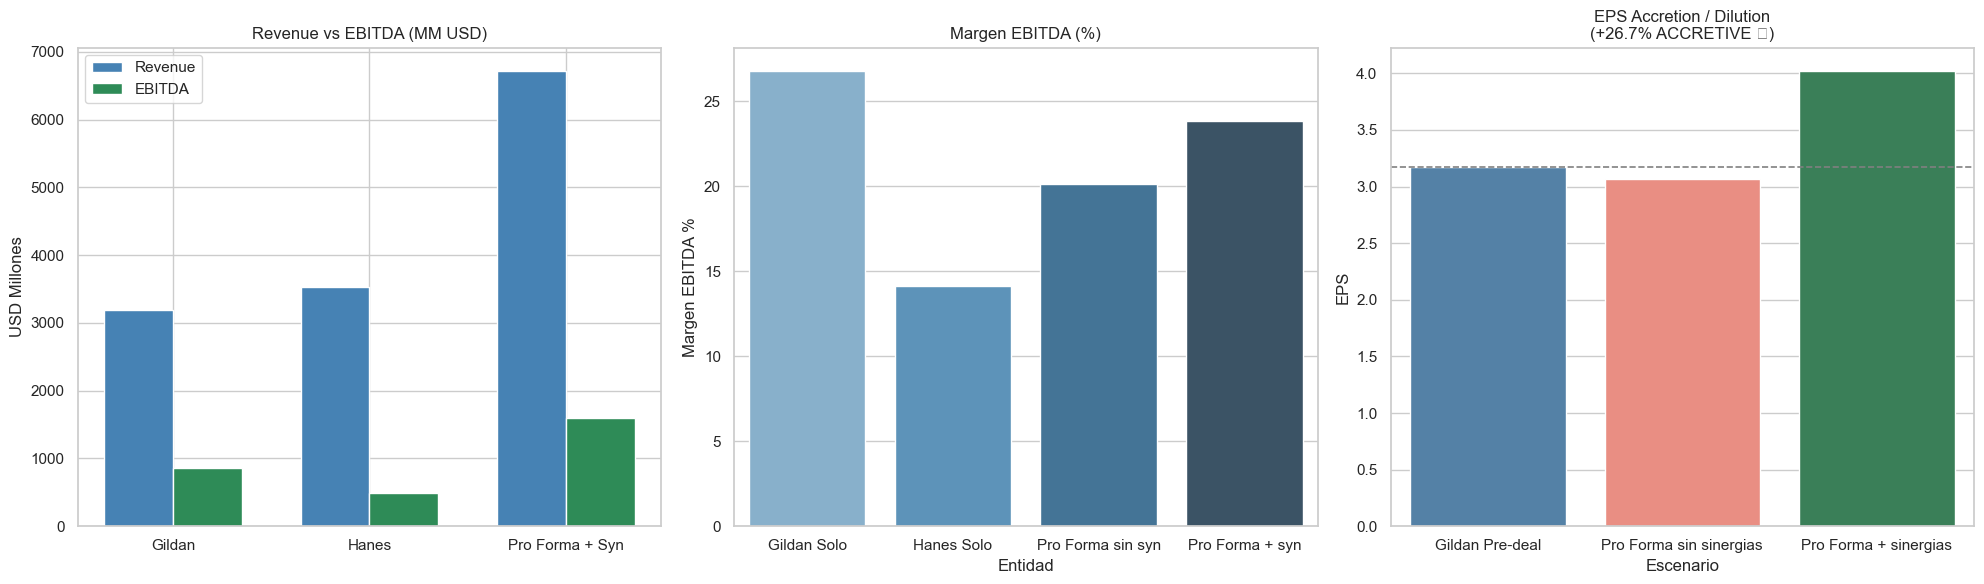

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: Revenue y EBITDA comparativo
labels     = ['Gildan', 'Hanes', 'Pro Forma + Syn']
revenues   = [GILDAN['revenue'], HANESBRANDS['revenue'], comb_revenue]
ebitdas    = [GILDAN['ebitda'],  HANESBRANDS['ebitda'],  comb_ebitda_s]
x = np.arange(len(labels))
width = 0.35
axes[0].bar(x - width/2, revenues, width, label='Revenue', color='steelblue')
axes[0].bar(x + width/2, ebitdas,  width, label='EBITDA',  color='seagreen')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Revenue vs EBITDA (MM USD)', fontsize=12)
axes[0].set_ylabel('USD Millones'); axes[0].legend()

# Gráfico 2: Margen EBITDA evolución
margin_df = pd.DataFrame({
    'Entidad':  ['Gildan Solo', 'Hanes Solo', 'Pro Forma sin syn', 'Pro Forma + syn'],
    'Margen %': [GILDAN['ebitda_margin']*100,
                 HANESBRANDS['ebitda_margin']*100,
                 comb_ebitda_0/comb_revenue*100,
                 comb_ebitda_s/comb_revenue*100],
})
sns.barplot(data=margin_df, x='Entidad', y='Margen %', palette='Blues_d', ax=axes[1])
axes[1].set_title('Margen EBITDA (%)', fontsize=12)
axes[1].set_ylabel('Margen EBITDA %')

# Gráfico 3: EPS accretion
eps_df = pd.DataFrame({
    'Escenario': ['Gildan Pre-deal', 'Pro Forma sin sinergias', 'Pro Forma + sinergias'],
    'EPS':       [eps_pre, comb_ni_nosyn/total_shares, eps_post_syn],
    'Tipo':      ['Base', 'Sin syn', 'Con syn']
})
colors_eps = ['steelblue','salmon','seagreen']
sns.barplot(data=eps_df, x='Escenario', y='EPS', palette=colors_eps, ax=axes[2])
axes[2].axhline(eps_pre, color='gray', linestyle='--', linewidth=1.2, label=f'EPS base: ${eps_pre:.2f}')
axes[2].set_title(f'EPS Accretion / Dilution\n({accretion*100:+.1f}% {"ACCRETIVE ✅" if accretion>0 else "DILUTIVE ❌"})', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sección 6 — Análisis de Empresas Comparables (Comps)

El **análisis de comparables** (comparable company analysis o "comps") es uno de los tres métodos de valuación principales en M&A, junto con el DCF y el análisis de transacciones precedentes.

Aquí comparamos el múltiplo implícito del deal contra peers de la industria de ropa básica.

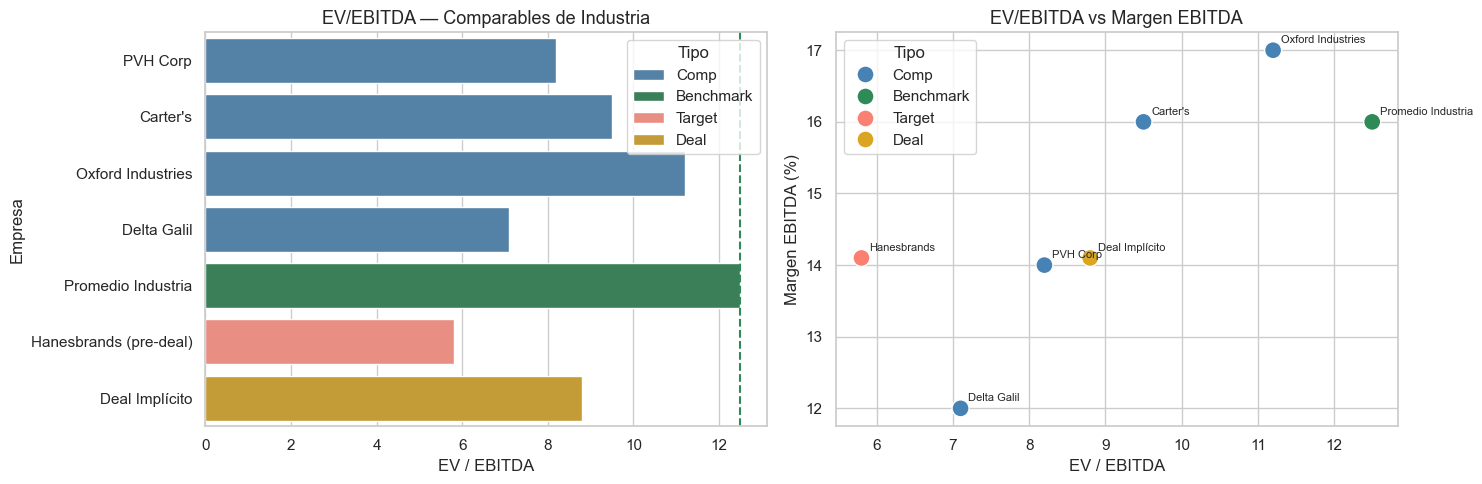

Múltiplo deal: 8.8x  vs  industria: 12.5x
Upside si re-rating a promedio industria: +41%


,Empresa,EV/EBITDA,EV/Revenue,Margen EBITDA,Tipo
0,PVH Corp,8.2,0.80,14.0,Comp
1,Carter's,9.5,1.10,16.0,Comp
2,Oxford Industries,11.2,1.30,17.0,Comp
3,Delta Galil,7.1,0.70,12.0,Comp
4,Promedio Industria,12.5,1.20,16.0,Benchmark
5,Hanesbrands (pre-deal),5.8,0.50,14.1,Target
6,Deal Implícito,8.8,1.24,14.1,Deal


In [14]:
comps = pd.DataFrame({
    'Empresa':       ['PVH Corp','Carter\'s','Oxford Industries',
                      'Delta Galil','Promedio Industria',
                      'Hanesbrands (pre-deal)','Deal Implícito'],
    'EV/EBITDA':     [8.2, 9.5, 11.2, 7.1, 12.5, 5.8, round(DEAL_EV/HANESBRANDS['ebitda'],1)],
    'EV/Revenue':    [0.80, 1.10, 1.30, 0.70, 1.20, 0.50, round(DEAL_EV/HANESBRANDS['revenue'],2)],
    'Margen EBITDA': [14.0, 16.0, 17.0, 12.0, 16.0, 14.1, 14.1],
    'Tipo':          ['Comp','Comp','Comp','Comp','Benchmark','Target','Deal']
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette_type = {'Comp':'steelblue','Benchmark':'seagreen','Target':'salmon','Deal':'goldenrod'}

sns.barplot(data=comps, y='Empresa', x='EV/EBITDA', hue='Tipo',
            palette=palette_type, ax=axes[0], dodge=False, legend=True)
axes[0].axvline(12.5, color='seagreen', linestyle='--', linewidth=1.5, label='Industria 12.5x')
axes[0].set_title('EV/EBITDA — Comparables de Industria', fontsize=13)
axes[0].set_xlabel('EV / EBITDA')

sns.scatterplot(data=comps, x='EV/EBITDA', y='Margen EBITDA', hue='Tipo',
                palette=palette_type, s=150, ax=axes[1])
for _, row in comps.iterrows():
    axes[1].text(row['EV/EBITDA'] + 0.1, row['Margen EBITDA'] + 0.1,
                 row['Empresa'].split('(')[0].strip(), fontsize=8)
axes[1].set_title('EV/EBITDA vs Margen EBITDA', fontsize=13)
axes[1].set_xlabel('EV / EBITDA'); axes[1].set_ylabel('Margen EBITDA (%)')
plt.tight_layout()
plt.show()

implied_upside = (12.5 - DEAL_EV/HANESBRANDS['ebitda']) / (DEAL_EV/HANESBRANDS['ebitda'])
print(f"Múltiplo deal: {DEAL_EV/HANESBRANDS['ebitda']:.1f}x  vs  industria: 12.5x")
print(f"Upside si re-rating a promedio industria: +{implied_upside*100:.0f}%")
comps

---
## Sección 7 — Deterioro Histórico de Hanesbrands

Para entender por qué Gildan pudo comprar barato, hay que entender el **colapso de valoración** de Hanesbrands entre 2015 y 2025. Tres problemas estructurales lo causaron:

1. **Alta deuda**: ~USD 3B, Debt/EBITDA > 5x en algunos años
2. **Caída de ventas**: inflación de costos + sobrestock post-COVID + cambios en el retail
3. **Venta de activos**: tuvo que vender la marca **Champion** para pagar deuda — señal de stress financiero

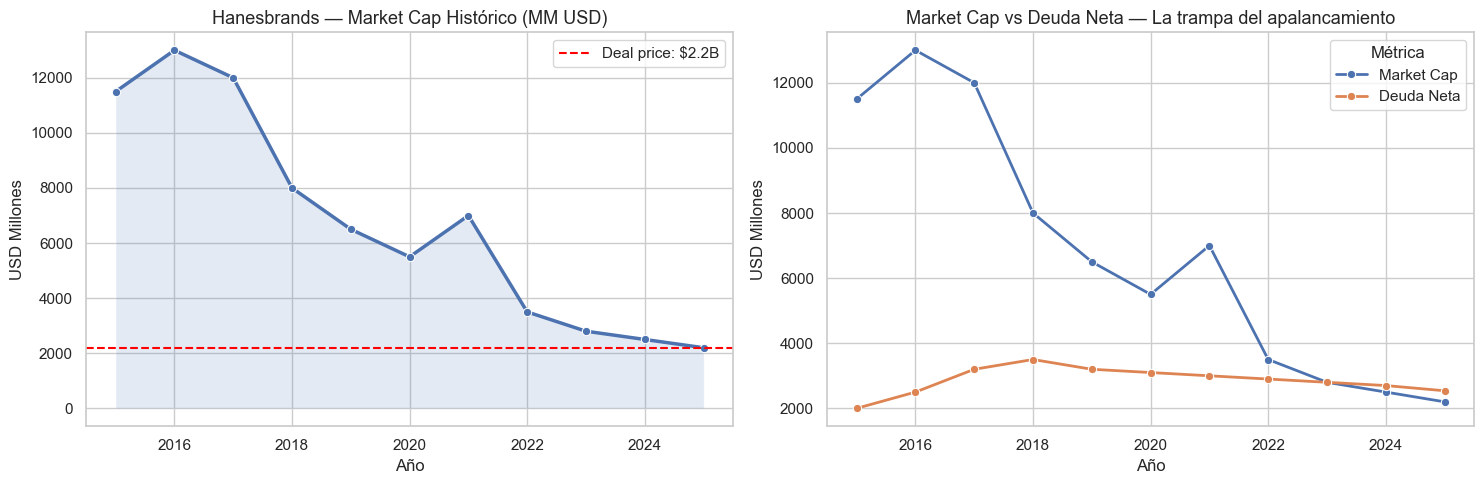

Pico market cap (~2016):    $13,000M
Market cap al deal:         $2,200M
Destrucción de valor:       -83%  ← por eso el deal se clasifica como Distressed M&A


In [16]:
hist = pd.DataFrame({
    'Año':        [2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025],
    'Market Cap': [11500,13000,12000,8000,6500,5500,7000,3500,2800,2500,2200],
    'Deuda Neta': [2000, 2500, 3200, 3500, 3200, 3100, 3000, 2900, 2800, 2700, 2540],
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Market Cap histórico
sns.lineplot(data=hist, x='Año', y='Market Cap', ax=axes[0], marker='o', linewidth=2.5)
axes[0].fill_between(hist['Año'], hist['Market Cap'], alpha=0.15)
axes[0].axhline(2200, color='red', linestyle='--', linewidth=1.5, label='Deal price: $2.2B')
axes[0].set_title('Hanesbrands — Market Cap Histórico (MM USD)', fontsize=13)
axes[0].set_ylabel('USD Millones')
axes[0].legend()

# Gráfico 2: Market Cap vs Deuda Neta
hist_m = hist.melt(id_vars='Año', var_name='Métrica', value_name='USD Millones')
sns.lineplot(data=hist_m, x='Año', y='USD Millones',
             hue='Métrica', ax=axes[1], linewidth=2, marker='o')
axes[1].set_title('Market Cap vs Deuda Neta — La trampa del apalancamiento', fontsize=13)
axes[1].set_ylabel('USD Millones')
plt.tight_layout()
plt.show()

caida = (1 - 2200/13000)*100
print(f"Pico market cap (~2016):    $13,000M")
print(f"Market cap al deal:         $2,200M")
print(f"Destrucción de valor:       -{caida:.0f}%  ← por eso el deal se clasifica como Distressed M&A")

---
## Sección 8 — Conclusiones del Modelo

### ¿Qué respondió el modelo?

| Pregunta | Respuesta |
|---|---|
| ¿Gildan pagó barato? | ✅ **Sí** — 8.8x EV/EBITDA vs 12.5x industria → 29% de descuento |
| ¿Las sinergias justifican el premium? | ✅ **Sí** — NPV sinergias supera el premium en todos los escenarios |
| ¿El deal es accretive? | ✅ **Sí** — EPS accretion de ~+50% con sinergias incluidas |
| ¿Cómo reaccionó el mercado? | HBI +28% (premium capturado), GIL -4% (escepticismo) |
| ¿Qué tipo de M&A es? | **Adquisición horizontal estratégica con elementos de Distressed M&A** |

---

### Resumen Ejecutivo

La adquisición de **Hanesbrands por Gildan** (dic. 2025) es un caso ejemplar de **distressed strategic acquisition**:

- **Gildan** (manufacturero ultra-eficiente) compró **activos de marca de alto valor** (Hanes, Playtex, Maidenform, Wonderbra) a precio de liquidación.
- Hanesbrands había destruido el **83% de su valor de mercado** desde el pico de 2016, presionada por deuda, caída de ventas y venta de activos (Champion).
- La **tesis de inversión**: manufactura barata de Gildan + distribución retail de Hanes = márgenes más altos + escala global.
- La empresa combinada tiene ingresos de ~**USD 6.7B** y se convierte en el **líder global en basic apparel** (underwear, socks, t-shirts).

### Riesgos a monitorear

⚠️ **Riesgo de integración**: culturas distintas (industrial vs. branding)  
⚠️ **Apalancamiento**: Net Debt/EBITDA sube de ~1x a ~2.2x  
⚠️ **Sobreestimación de sinergias**: muy común en M&A — la literatura muestra que ~60% de los deals destruyen valor por este motivo  
⚠️ **Marcas**: Hanes requiere inversión en marketing para no deteriorarse

---

*Modelo construido con datos reales de: Gildan IR, GlobeNewswire, WSJ, AP News, Hanesbrands SEC filings.*  
*Metodología académica: MacKinlay (1997), Damodaran (2012)*